<a href="https://colab.research.google.com/github/Mahathi1122/Kindle-Review-Sentiment-Analyis./blob/main/Kindle_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler,MinMaxScaler


In [6]:
import pandas as pd

# Step 1: Install gdown (for downloading from Google Drive)
!pip install -q gdown

# Step 2: Use gdown to download the file using its ID
file_id = '1knGer_TGj9202lEUgVxsyB5p3LHspnQW'
output = 'all_kindle_review.csv'
!gdown --id {file_id} -O {output}

# Step 3: Read the CSV file
data = pd.read_csv(output)

# Step 4: Display the first few rows
data.head()


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1knGer_TGj9202lEUgVxsyB5p3LHspnQW
To: /content/all_kindle_review.csv
100% 8.59M/8.59M [00:00<00:00, 40.8MB/s]


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [7]:
data

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000
...,...,...,...,...,...,...,...,...,...,...,...
11995,11995,2183,B001DUGORO,"[0, 0]",4,Valentine cupid is a vampire- Jena and Ian ano...,"02 28, 2014",A1OKS5Q1HD8WQC,lisa jon jung,jena,1393545600
11996,11996,6272,B002JCSFSQ,"[2, 2]",5,I have read all seven books in this series. Ap...,"05 16, 2011",AQRSPXLNEQAMA,TerryLP,Peacekeepers Series,1305504000
11997,11997,12483,B0035N1V7K,"[0, 1]",3,This book really just wasn't my cuppa. The si...,"07 26, 2013",A2T5QLT5VXOJAK,hwilson,a little creepy,1374796800
11998,11998,3640,B001W1XT40,"[1, 2]",1,"tried to use it to charge my kindle, it didn't...","09 17, 2013",A28MHD2DDY6DXB,"Allison A. Slater ""Gryphon50""",didn't work,1379376000


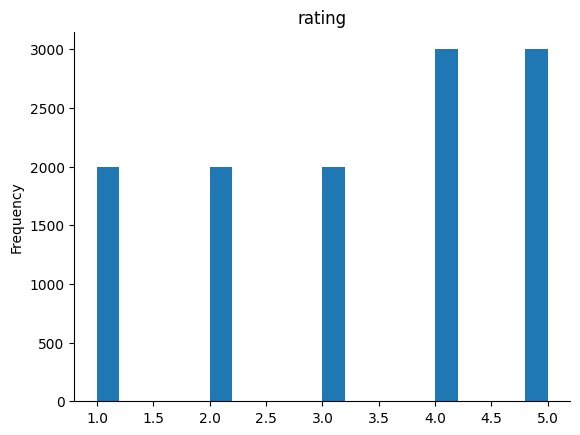

In [9]:
# @title rating

from matplotlib import pyplot as plt
data['rating'].plot(kind='hist', bins=20, title='rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [10]:
data=data[["rating","reviewText"]]

In [11]:
data.isna().sum()

,0
rating,0
reviewText,0


In [12]:
data["rating"].value_counts()

,count
rating,
5,3000
4,3000
3,2000
2,2000
1,2000


In [13]:
data["rating"]==data["rating"].apply(lambda x:0 if x<3 else 1)


,rating
0,False
1,False
2,False
3,False
4,False
...,...
11995,False
11996,False
11997,False
11998,False


In [14]:
data.head()

,rating,reviewText
0,3,"Jace Rankin may be short, but he's nothing to ..."
1,5,Great short read. I didn't want to put it dow...
2,3,I'll start by saying this is the first of four...
3,3,Aggie is Angela Lansbury who carries pocketboo...
4,4,I did not expect this type of book to be in li...


from matplotlib import pyplot as plt
_df_0['rating'].plot(kind='hist', bins=20, title='rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('reviewText').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['rating'].plot(kind='line', figsize=(8, 4), title='rating')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['reviewText'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='rating', y='reviewText', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [15]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For lemmatization support

lemmatizer = WordNetLemmatizer()


corpus = []

for i in range(len(data)):
    review = data["reviewText"][i]

    # Remove URLs
    review = re.sub(r"http\S+|www\S+|https\S+", "", review, flags=re.MULTILINE)



    # Keep only letters and numbers, replace others with space
    review = re.sub(r"[^a-zA-Z0-9]", " ", review)

    # Convert to lowercase
    review = review.lower()

    # Tokenize and remove stopwords, then lemmatize
    words = review.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords.words("english")]

    # Re-join cleaned words
    cleaned_review = " ".join(words)

    # Remove extra spaces
    cleaned_review = re.sub(r"\s+", " ", cleaned_review).strip()

    corpus.append(cleaned_review)

from bs4 import BeautifulSoup

if isinstance(review, str):
    review = BeautifulSoup(review, "html.parser").get_text()
else:
    review = ""


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [16]:
data.loc[:, 'cleaned_review'] = corpus
final_data = data[['rating', 'cleaned_review']]
final_data

,rating,cleaned_review
0,3,jace rankin may short nothing mess man hauled ...
1,5,great short read want put read one sitting sex...
2,3,start saying first four book expecting 34 conc...
3,3,aggie angela lansbury carry pocketbook instead...
4,4,expect type book library pleased find price right
...,...,...
11995,4,valentine cupid vampire jena ian another vampi...
11996,5,read seven book series apocalyptic adventure o...
11997,3,book really cuppa situation man capturing woma...
11998,1,tried use charge kindle even register charging...


In [17]:
X_train,X_test,y_train,y_test=train_test_split(data["cleaned_review"],data["rating"],test_size=0.2,random_state=42)


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split(data["cleaned_review"], data["rating"], test_size=0.2, random_state=42)

# Step 2: Vectorize the text
cv = CountVectorizer()
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

# Step 3: Train the model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Step 4: Predict
y_pred = model.predict(X_test_vec)

# Step 5: Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[203 117  35  33  16]
 [ 87 158  68  58  28]
 [ 31  66 107 140  43]
 [ 13  32  80 314 148]
 [  6   9  25 207 376]]
              precision    recall  f1-score   support

           1       0.60      0.50      0.55       404
           2       0.41      0.40      0.40       399
           3       0.34      0.28      0.30       387
           4       0.42      0.53      0.47       587
           5       0.62      0.60      0.61       623

    accuracy                           0.48      2400
   macro avg       0.48      0.46      0.47      2400
weighted avg       0.49      0.48      0.48      2400



In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split(data["cleaned_review"], data["rating"], test_size=0.2, random_state=42)

# Step 2: Vectorize the text
cv = TfidfVectorizer()
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

# Step 3: Train the model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Step 4: Predict
y_pred = model.predict(X_test_vec)

# Step 5: Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[132  41   1 201  29]
 [ 40  43   2 276  38]
 [ 10   8   8 326  35]
 [  2   2   1 443 139]
 [  0   0   0 282 341]]
              precision    recall  f1-score   support

           1       0.72      0.33      0.45       404
           2       0.46      0.11      0.17       399
           3       0.67      0.02      0.04       387
           4       0.29      0.75      0.42       587
           5       0.59      0.55      0.57       623

    accuracy                           0.40      2400
   macro avg       0.54      0.35      0.33      2400
weighted avg       0.53      0.40      0.36      2400



In [20]:
!pip install --upgrade scipy
!pip install --upgrade gensim
!pip install --upgrade scikit-learn



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 12.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
# Upgrade numpy and gensim to compatible versions
!pip install --upgrade --force-reinstall numpy gensim


  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp311-cp

In [1]:
import gensim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# STEP 1: Install necessary packages
!pip install --upgrade --force-reinstall numpy gensim gdown

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# STEP 3: Download dataset from Google Drive using gdown
!gdown --id 1knGer_TGj9202lEUgVxsyB5p3LHspnQW -O all_kindle_review.csv

# STEP 4: Load CSV file
data = pd.read_csv("all_kindle_review.csv")


# STEP 6: Load pre-trained Word2Vec model from gensim
print("Loading Word2Vec model...")
word2vec_model = api.load('word2vec-google-news-300')
print("Model loaded.")

# STEP 7: Function to get average Word2Vec vector of a review
def get_avg_vector(review, model):
    words = str(review).split()
    vectors = [model[word] for word in words if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(300)

# STEP 8: Convert all reviews to vectors
print("Vectorizing reviews...")
X = np.array([get_avg_vector(review, word2vec_model) for review in data['cleaned_review']])
y = data['rating']

# STEP 9: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 10: Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# STEP 11: Evaluate model
y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached beautifulsoup4-4.13.4-py3-none-any.whl.metadata (3.8 kB)
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
  Using cached soupsieve-2.7-py3-none-any.whl.m

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Traceback (most recent call last):
  File "/usr/local/bin/gdown", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gdown/__main__.py", line 172, in main
    download(
  File "/usr/local/lib/python3.11/dist-packages/gdown/download.py", line 202, in download
    res = sess.get(url, stream=True, verify=verify)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/requests/sessions.py", line 602, in get
    return self.request("GET", url, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/requests/sessions.py", line 589, in request
    resp = self.send(prep, **send_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1knGer_TGj9202lEUgVxsyB5p3LHspnQW
To: /content/all_kindle_review.csv
100% 8.59M/8.59M [00:00<00:00, 31.7MB/s]
Available columns: Index(['Unnamed: 0.1', 'Unnamed: 0', 'asin', 'helpful', 'rating', 'reviewText',
       'reviewTime', 'reviewerID', 'reviewerName', 'summary',
       'unixReviewTime'],
      dtype='object')
   rating                                         reviewText  \
0       3  Jace Rankin may be short, but he's nothing to ...   
1       5  Great short read.  I didn't want to put it dow...   
2       3  I'll start by saying this is the first of four...   
3       3  Aggie is Angela Lansbury who carries pocketboo...   
4       4  I did not expect this type of book to be in li...   

                       

<ipython-input-1-433249e30867>:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment', order=['positive', 'neutral', 'negative'], palette='pastel')


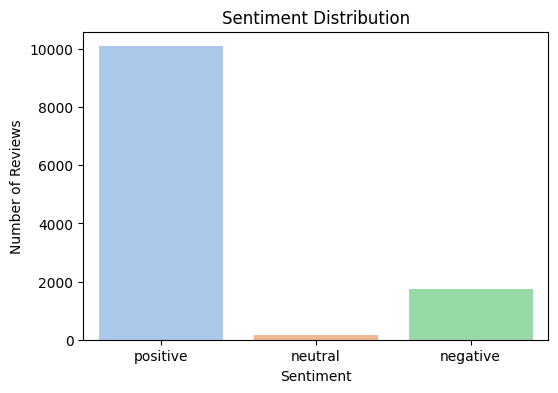

<ipython-input-1-433249e30867>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='sentiment', y=rating_col, order=['positive', 'neutral', 'negative'], palette='muted')


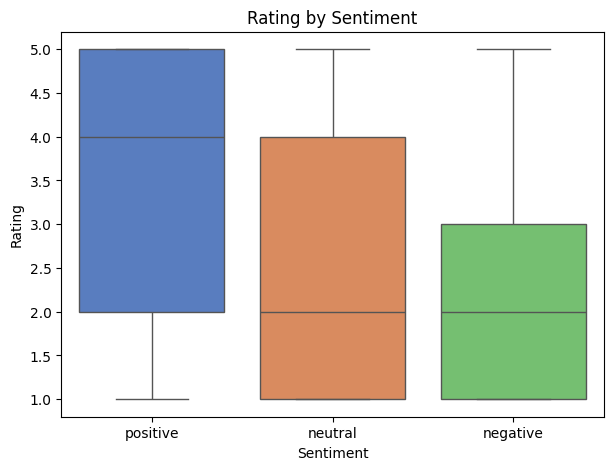


📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.97      0.94      2023
    positive       0.97      0.91      0.94      2013

    accuracy                           0.94      4036
   macro avg       0.94      0.94      0.94      4036
weighted avg       0.94      0.94      0.94      4036

✅ Accuracy: 94.05 %

🔍 Confusion Matrix:
[[1959   64]
 [ 176 1837]]


In [1]:
# STEP 1: Install required packages
!pip install -q textblob gdown seaborn matplotlib beautifulsoup4 scikit-learn imbalanced-learn

# STEP 2: Download dataset from Google Drive
!gdown --id 1knGer_TGj9202lEUgVxsyB5p3LHspnQW -O all_kindle_review.csv

# STEP 3: Import libraries
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# STEP 4: Load dataset
data = pd.read_csv("all_kindle_review.csv")

# STEP 5: Confirm column names
print("Available columns:", data.columns)

# ✅ Replace with actual column names if needed
review_col = 'reviewText'    # Text of review
rating_col = 'rating'        # Rating column

# STEP 6: Drop missing values
data = data.dropna(subset=[review_col, rating_col]).reset_index(drop=True)

# STEP 7: Clean review text
def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()  # Remove HTML
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # Remove URLs
    text = re.sub(r"[^a-z0-9\s.,!?']", '', text)  # Keep letters/numbers/punctuation
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

data['clean_review'] = data[review_col].apply(clean_text)

# STEP 8: Sentiment score
data['sentiment_score'] = data['clean_review'].apply(lambda x: TextBlob(x).sentiment.polarity)

# STEP 9: Classify sentiment
def classify_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

data['sentiment'] = data['sentiment_score'].apply(classify_sentiment)

# STEP 10: Display preview
print(data[[rating_col, review_col, 'clean_review', 'sentiment_score', 'sentiment']].head())

# STEP 11: Plot sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='sentiment', order=['positive', 'neutral', 'negative'], palette='pastel')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# STEP 12: Rating distribution by sentiment
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x='sentiment', y=rating_col, order=['positive', 'neutral', 'negative'], palette='muted')
plt.title("Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Rating")
plt.show()

# STEP 13: Save cleaned dataset
data.to_csv("cleaned_kindle_reviews_with_sentiment.csv", index=False)

# STEP 14: Prepare for classification (binary: positive vs. negative)
df_model = data[data['sentiment'] != 'neutral'].copy()
X = df_model['clean_review']
y = df_model['sentiment']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

# STEP 15: Apply SMOTE (after vectorizing)
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_vec, y)

# STEP 16: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# STEP 17: Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# STEP 18: Predict and evaluate
y_pred = model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("✅ Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\n🔍 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [2]:
!pip install wordcloud


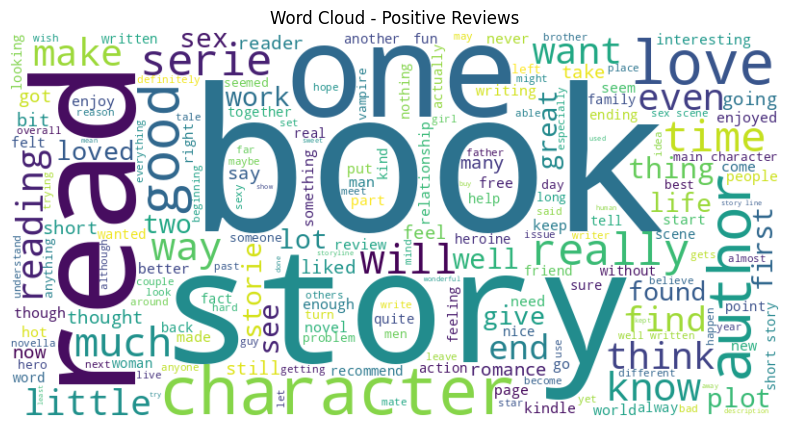

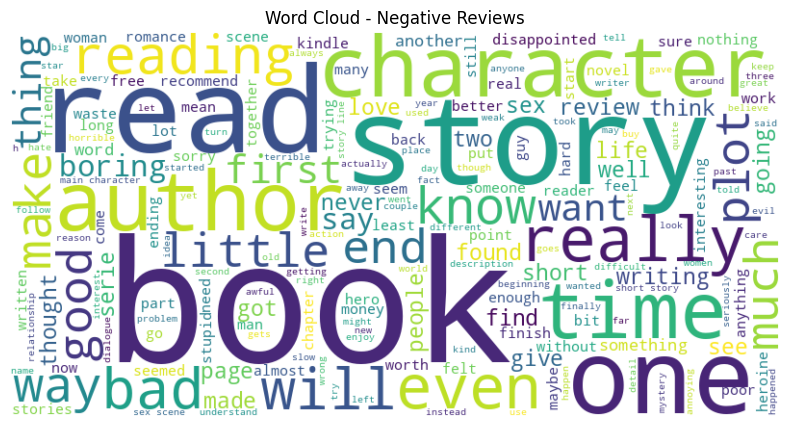

In [3]:
from wordcloud import WordCloud

# Generate word clouds
for label in ['positive', 'negative']:
    text = " ".join(df_model[df_model['sentiment'] == label]['clean_review'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {label.capitalize()} Reviews')
    plt.show()
